# Dynamic VaR Forecasting with GARCH, Machine Learning, and Neural Stochastic Models

This notebook compares classical econometric, machine-learning, and neural stochastic approaches to one-day-ahead 99% Value-at-Risk (VaR) forecasting.

## Experimental design

- **Initial training:** 2016–2021
- **Validation / calibration:** 2022–2023
- **Final out-of-sample test:** 2024–2026

The final comparison uses the same 2024–2026 return dates for all models.

Models:
1. Historical / Gaussian / Student-t tail benchmarks
2. GARCH(1,1)-t
3. Random Forest volatility forecasting
4. Gaussian neural conditional diffusion
5. Student-t neural conditional diffusion

The neural models are one-step conditional diffusion models motivated by an Euler discretization of an SDE; they are not full continuous-time neural-SDE solvers.

## 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm, t, chi2, probplot
from statsmodels.graphics.tsaplots import plot_acf
from arch import arch_model

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn

SEED = 42
ALPHA = 0.01

np.random.seed(SEED)
torch.manual_seed(SEED)

pd.set_option("display.float_format", lambda x: f"{x:.6f}")

### Data path

For GitHub, keep the Excel file inside a `data/` folder:

```text
dynamic-var-forecasting/
├── data/
│   └── Combined_dataset.xlsx
└── notebooks/
    └── dynamic_var_forecasting_clean.ipynb
```

If you run the notebook from a different working directory, adjust `DATA_PATH`.

In [3]:
DATA_PATH = Path("C:/Users/PCNUREM-02/Desktop/Combined_dataset.xlsx")

df = pd.read_excel(DATA_PATH)

duplicate_date_cols = [f"Date.{i}" for i in range(1, 10)]
df = df.drop(columns=[c for c in duplicate_date_cols if c in df.columns])

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").set_index("Date")

print(df.head())
print()
print(df.dtypes)

                 CAT       WMT        CVX       XOM       PFE        JNJ  \
Date                                                                       
2016-08-11 83.240000 24.600000 101.400000 86.720000 33.320000 123.770000   
2016-08-12 83.000000 24.630000 102.160000 87.850000 33.160000 123.220000   
2016-08-15 84.150000 24.440000 102.770000 87.810000 33.280000 122.310000   
2016-08-16 84.290000 24.300000 102.620000 87.920000 32.980000 120.330000   
2016-08-17 84.410000 24.310000 102.220000 88.110000 33.310000 121.310000   

                 BAC       JPM      MSFT      AAPL  
Date                                                
2016-08-11 14.880000 65.460000 58.300000 26.980000  
2016-08-12 14.910000 65.320000 57.940000 27.050000  
2016-08-15 15.020000 65.720000 58.120000 27.370000  
2016-08-16 15.170000 65.710000 57.440000 27.340000  
2016-08-17 15.150000 65.890000 57.560000 27.310000  

CAT     float64
WMT     float64
CVX     float64
XOM     float64
PFE     float64
JNJ     float64

## 2. Portfolio construction

In [4]:
log_returns = np.log(df / df.shift(1)).dropna()

n_assets = log_returns.shape[1]
weights = np.repeat(1 / n_assets, n_assets)

portfolio_returns = (log_returns @ weights).rename("portfolio_return")

print("Assets:", list(log_returns.columns))
print("Weights:", weights)
print(portfolio_returns.head())

Assets: ['CAT', 'WMT', 'CVX', 'XOM', 'PFE', 'JNJ', 'BAC', 'JPM', 'MSFT', 'AAPL']
Weights: [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Date
2016-08-12    0.000575
2016-08-15    0.003603
2016-08-16   -0.003275
2016-08-17    0.002056
2016-08-18    0.002586
Name: portfolio_return, dtype: float64


## 3. Static tail-risk benchmarks

In [5]:
confidence = 0.99

# Historical VaR and ES
hist_cutoff = np.quantile(portfolio_returns, ALPHA)
hist_var_99 = -hist_cutoff
hist_es_99 = -portfolio_returns[portfolio_returns <= hist_cutoff].mean()

# Gaussian parametric VaR and ES
mu = portfolio_returns.mean()
sigma = portfolio_returns.std()
z_alpha = norm.ppf(ALPHA)

gaussian_var_99 = -(mu + z_alpha * sigma)
gaussian_es_99 = -(mu - sigma * norm.pdf(z_alpha) / ALPHA)

# Gaussian Monte Carlo benchmark
mu_vector = log_returns.mean()
cov_matrix = log_returns.cov()
rng = np.random.default_rng(SEED)

simulated_asset_returns = rng.multivariate_normal(
    mean=mu_vector,
    cov=cov_matrix,
    size=100_000,
)
simulated_portfolio_returns = simulated_asset_returns @ weights

mc_cutoff = np.quantile(simulated_portfolio_returns, ALPHA)
mc_var_99 = -mc_cutoff
mc_es_99 = -simulated_portfolio_returns[
    simulated_portfolio_returns <= mc_cutoff
].mean()

# Static Student-t benchmark
nu_static, loc_static, scale_static = t.fit(portfolio_returns)
student_t_cutoff = t.ppf(
    ALPHA,
    df=nu_static,
    loc=loc_static,
    scale=scale_static,
)
student_t_var_99 = -student_t_cutoff

q_std_t = t.ppf(ALPHA, nu_static)
student_t_es_99 = -(
    loc_static
    - scale_static
    * t.pdf(q_std_t, nu_static)
    * (nu_static + q_std_t**2)
    / ((nu_static - 1) * ALPHA)
)

static_results = pd.DataFrame(
    {
        "VaR_99": [
            hist_var_99,
            gaussian_var_99,
            mc_var_99,
            student_t_var_99,
        ],
        "ES_99": [
            hist_es_99,
            gaussian_es_99,
            mc_es_99,
            student_t_es_99,
        ],
    },
    index=[
        "Historical",
        "Gaussian",
        "Gaussian Monte Carlo",
        "Student-t",
    ],
)

print(static_results)
print()
print("Static Student-t degrees of freedom:", nu_static)

                       VaR_99    ES_99
Historical           0.030882 0.049211
Gaussian             0.025715 0.029538
Gaussian Monte Carlo 0.025712 0.029476
Student-t            0.030023 0.049009

Static Student-t degrees of freedom: 2.7315586612055123


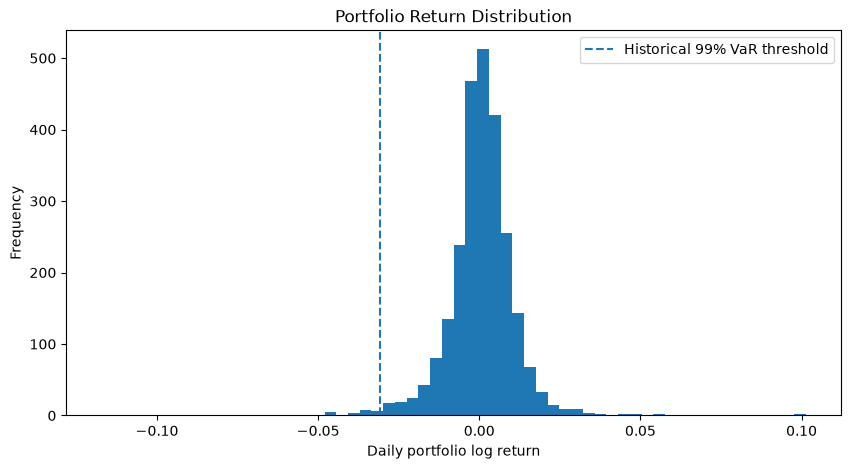

In [6]:
plt.figure(figsize=(10, 5))
plt.hist(portfolio_returns, bins=60)
plt.axvline(-hist_var_99, linestyle="--", label="Historical 99% VaR threshold")
plt.xlabel("Daily portfolio log return")
plt.ylabel("Frequency")
plt.title("Portfolio Return Distribution")
plt.legend()
plt.show()

### Normal and Student-t QQ diagnostics

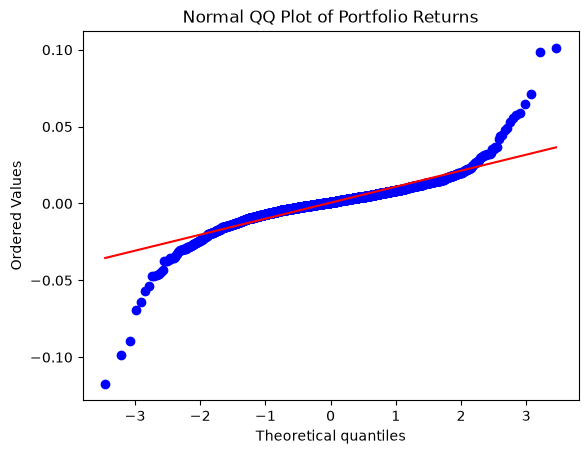

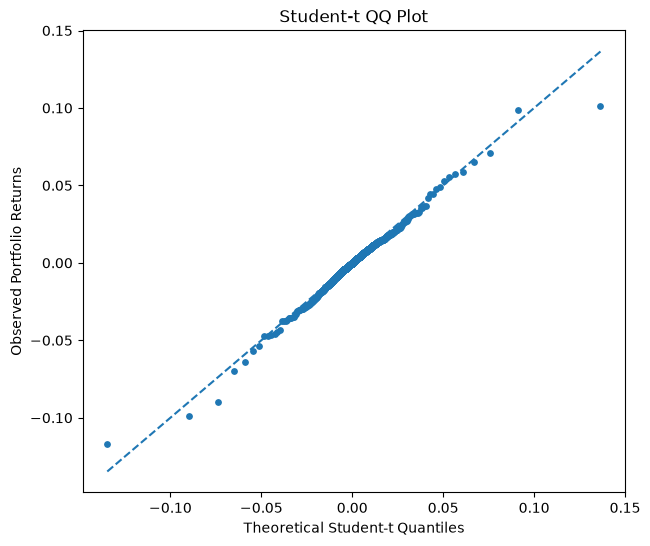

In [7]:
probplot(portfolio_returns, dist="norm", plot=plt)
plt.title("Normal QQ Plot of Portfolio Returns")
plt.show()

sorted_returns = np.sort(portfolio_returns.to_numpy())
n = len(sorted_returns)
probabilities = (np.arange(1, n + 1) - 0.5) / n

theoretical_t = t.ppf(
    probabilities,
    df=nu_static,
    loc=loc_static,
    scale=scale_static,
)

plt.figure(figsize=(7, 6))
plt.scatter(theoretical_t, sorted_returns, s=15)

lo = min(theoretical_t.min(), sorted_returns.min())
hi = max(theoretical_t.max(), sorted_returns.max())
plt.plot([lo, hi], [lo, hi], linestyle="--")

plt.xlabel("Theoretical Student-t Quantiles")
plt.ylabel("Observed Portfolio Returns")
plt.title("Student-t QQ Plot")
plt.show()

## 4. Volatility clustering and GARCH diagnostics

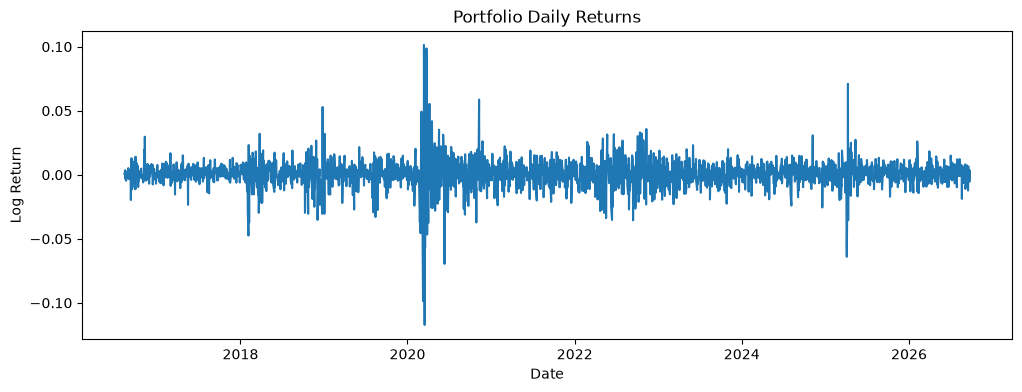

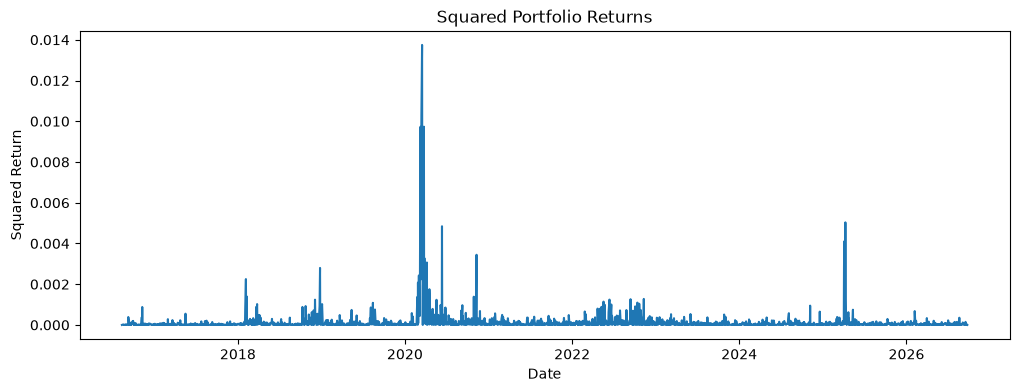

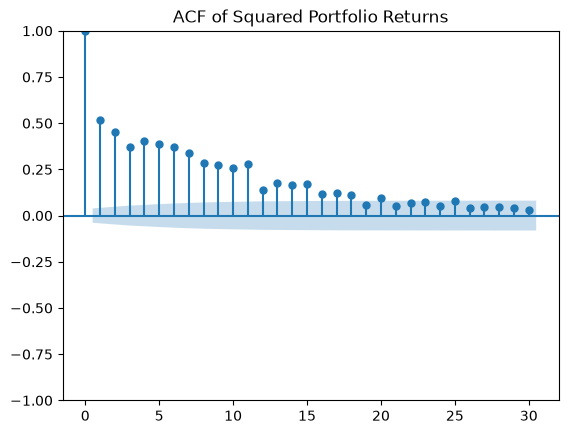

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(portfolio_returns.index, portfolio_returns)
plt.title("Portfolio Daily Returns")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(portfolio_returns.index, portfolio_returns**2)
plt.title("Squared Portfolio Returns")
plt.xlabel("Date")
plt.ylabel("Squared Return")
plt.show()

plot_acf(portfolio_returns**2, lags=30)
plt.title("ACF of Squared Portfolio Returns")
plt.show()

For diagnostics, fit a GARCH(1,1)-t model on data available **before the final test period**.

In [9]:
returns_pct = (portfolio_returns * 100).rename("return_pct")

garch_train = returns_pct[returns_pct.index < "2024-01-01"]

garch_model = arch_model(
    garch_train,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="t",
)

garch_fit = garch_model.fit(disp="off")
print(garch_fit.summary())

garch_alpha = garch_fit.params["alpha[1]"]
garch_beta = garch_fit.params["beta[1]"]

print("Volatility persistence (alpha + beta):", garch_alpha + garch_beta)

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                   return_pct   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -2450.62
Distribution:      Standardized Student's t   AIC:                           4911.24
Method:                  Maximum Likelihood   BIC:                           4938.88
                                              No. Observations:                 1858
Date:                      Sun, Sep 27 2026   Df Residuals:                     1857
Time:                              21:45:09   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

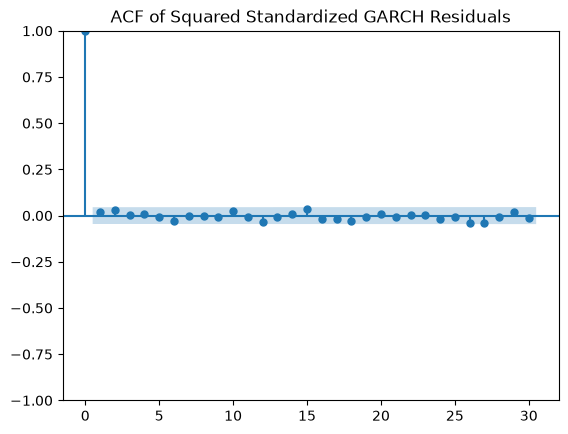

In [10]:
standardized_residuals = (
    garch_fit.resid / garch_fit.conditional_volatility
)

plot_acf(standardized_residuals.dropna()**2, lags=30)
plt.title("ACF of Squared Standardized GARCH Residuals")
plt.show()

## 5. Reusable VaR backtesting functions

In [11]:
def quantile_loss(actual, forecast, alpha=ALPHA):
    actual = pd.Series(actual)
    forecast = pd.Series(forecast, index=actual.index)
    return (
        (alpha - (actual < forecast).astype(int))
        * (actual - forecast)
    )


def kupiec_test(violations, alpha=ALPHA):
    v = pd.Series(violations).astype(int)
    n = len(v)
    x = int(v.sum())

    # Numerical protection for x=0 or x=n
    eps = 1e-12
    p_hat = np.clip(x / n, eps, 1 - eps)
    alpha = np.clip(alpha, eps, 1 - eps)

    lr_uc = -2 * (
        (n - x) * np.log((1 - alpha) / (1 - p_hat))
        + x * np.log(alpha / p_hat)
    )
    p_value = 1 - chi2.cdf(lr_uc, df=1)

    return {
        "lr_uc": lr_uc,
        "p_uc": p_value,
        "violations": x,
        "n": n,
        "violation_rate": x / n,
    }


def christoffersen_independence_test(violations):
    v = pd.Series(violations).astype(int).to_numpy()

    n00 = np.sum((v[:-1] == 0) & (v[1:] == 0))
    n01 = np.sum((v[:-1] == 0) & (v[1:] == 1))
    n10 = np.sum((v[:-1] == 1) & (v[1:] == 0))
    n11 = np.sum((v[:-1] == 1) & (v[1:] == 1))

    eps = 1e-12

    pi01 = n01 / max(n00 + n01, 1)
    pi11 = n11 / max(n10 + n11, 1)
    pi = (n01 + n11) / max(n00 + n01 + n10 + n11, 1)

    pi01 = np.clip(pi01, eps, 1 - eps)
    pi11 = np.clip(pi11, eps, 1 - eps)
    pi = np.clip(pi, eps, 1 - eps)

    log_l_ind = (
        (n00 + n10) * np.log(1 - pi)
        + (n01 + n11) * np.log(pi)
    )

    log_l_markov = (
        n00 * np.log(1 - pi01)
        + n01 * np.log(pi01)
        + n10 * np.log(1 - pi11)
        + n11 * np.log(pi11)
    )

    lr_ind = -2 * (log_l_ind - log_l_markov)
    p_value = 1 - chi2.cdf(lr_ind, df=1)

    return {
        "lr_ind": lr_ind,
        "p_ind": p_value,
        "n00": int(n00),
        "n01": int(n01),
        "n10": int(n10),
        "n11": int(n11),
    }


def var_backtest(actual, forecast, alpha=ALPHA):
    actual = pd.Series(actual).dropna()
    forecast = pd.Series(forecast).reindex(actual.index)

    aligned = pd.concat(
        [actual.rename("actual"), forecast.rename("var")],
        axis=1,
    ).dropna()

    violations = aligned["actual"] < aligned["var"]

    uc = kupiec_test(violations, alpha)
    ind = christoffersen_independence_test(violations)

    lr_cc = uc["lr_uc"] + ind["lr_ind"]
    p_cc = 1 - chi2.cdf(lr_cc, df=2)

    loss = quantile_loss(
        aligned["actual"],
        aligned["var"],
        alpha,
    )

    return {
        **uc,
        **ind,
        "lr_cc": lr_cc,
        "p_cc": p_cc,
        "mean_quantile_loss": loss.mean(),
        "loss_series": loss,
        "violations_series": violations,
    }

## 6. Fixed-parameter GARCH-t final test

To make the final comparison fairer, the GARCH parameters are estimated once using data through 2023 and then **kept fixed** during 2024–2026.

The volatility state is updated each day using the newly observed return, but the fitted parameters are not re-estimated during the test period.

In [12]:
garch_params = garch_fit.params

mu_g = garch_params["mu"]
omega_g = garch_params["omega"]
alpha_g = garch_params["alpha[1]"]
beta_g = garch_params["beta[1]"]
nu_g = garch_params["nu"]

q_g = t.ppf(ALPHA, df=nu_g) * np.sqrt((nu_g - 2) / nu_g)

# Last in-sample filtered state
var_prev = float(garch_fit.conditional_volatility.iloc[-1] ** 2)
eps_prev = float(garch_fit.resid.iloc[-1])

garch_test_returns = returns_pct[returns_pct.index >= "2024-01-01"]

garch_var_pct = []

for date, actual_return in garch_test_returns.items():
    var_t = omega_g + alpha_g * eps_prev**2 + beta_g * var_prev
    sigma_t = np.sqrt(var_t)

    var_threshold_pct = mu_g + sigma_t * q_g
    garch_var_pct.append(var_threshold_pct)

    # Update state using the return that has now been observed.
    eps_prev = actual_return - mu_g
    var_prev = var_t

garch_var_fixed = pd.Series(
    np.array(garch_var_pct) / 100,
    index=garch_test_returns.index,
    name="GARCH_VaR",
)

print(garch_var_fixed.head())

Date
2024-01-02   -0.016957
2024-01-03   -0.016450
2024-01-04   -0.015834
2024-01-05   -0.016298
2024-01-08   -0.015740
Name: GARCH_VaR, dtype: float64


## 7. Machine-learning dataset

In [13]:
ml_data = pd.DataFrame(index=portfolio_returns.index)

ml_data["r_t"] = portfolio_returns
ml_data["r_lag1"] = portfolio_returns.shift(1)
ml_data["r_lag2"] = portfolio_returns.shift(2)
ml_data["r_lag3"] = portfolio_returns.shift(3)

ml_data["abs_return"] = portfolio_returns.abs()
ml_data["squared_return"] = portfolio_returns**2

ml_data["vol_5"] = portfolio_returns.rolling(5).std()
ml_data["vol_10"] = portfolio_returns.rolling(10).std()
ml_data["vol_20"] = portfolio_returns.rolling(20).std()
ml_data["vol_60"] = portfolio_returns.rolling(60).std()

# Targets are created together before any split.
ml_data["target_variance"] = portfolio_returns.shift(-1) ** 2
ml_data["target_return"] = portfolio_returns.shift(-1)

ml_data = ml_data.dropna()

feature_cols = [
    "r_t",
    "r_lag1",
    "r_lag2",
    "r_lag3",
    "abs_return",
    "squared_return",
    "vol_5",
    "vol_10",
    "vol_20",
    "vol_60",
]

train = ml_data[ml_data.index < "2022-01-01"]
validation = ml_data[
    (ml_data.index >= "2022-01-01")
    & (ml_data.index < "2024-01-01")
]
test = ml_data[ml_data.index >= "2024-01-01"]

X_train = train[feature_cols]
y_train_var = train["target_variance"]

X_val = validation[feature_cols]
y_val_var = validation["target_variance"]

X_test = test[feature_cols]

print("Train:", train.index.min(), "to", train.index.max(), len(train))
print("Validation:", validation.index.min(), "to", validation.index.max(), len(validation))
print("Test:", test.index.min(), "to", test.index.max(), len(test))

Train: 2016-11-04 00:00:00 to 2021-12-31 00:00:00 1298
Validation: 2022-01-03 00:00:00 to 2023-12-29 00:00:00 501
Test: 2024-01-02 00:00:00 to 2026-09-23 00:00:00 684


## 8. Random Forest volatility model

In [14]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=6,
    min_samples_leaf=10,
    random_state=SEED,
    n_jobs=-1,
)

rf.fit(X_train, y_train_var)

val_predictions = np.maximum(rf.predict(X_val), 0)

rf_mse = mean_squared_error(y_val_var, val_predictions)
rf_mae = mean_absolute_error(y_val_var, val_predictions)
rf_r2 = r2_score(y_val_var, val_predictions)

baseline_predictions = np.repeat(y_train_var.mean(), len(y_val_var))
baseline_mse = mean_squared_error(y_val_var, baseline_predictions)
baseline_mae = mean_absolute_error(y_val_var, baseline_predictions)

print("RF validation MSE:", rf_mse)
print("Baseline MSE:", baseline_mse)
print("RF validation MAE:", rf_mae)
print("Baseline MAE:", baseline_mae)
print("RF validation R^2:", rf_r2)

RF validation MSE: 4.26646529667271e-08
Baseline MSE: 4.433479855228604e-08
RF validation MAE: 0.00013106659662004
Baseline MAE: 0.00015385911216557065
RF validation R^2: -0.02369010992261078


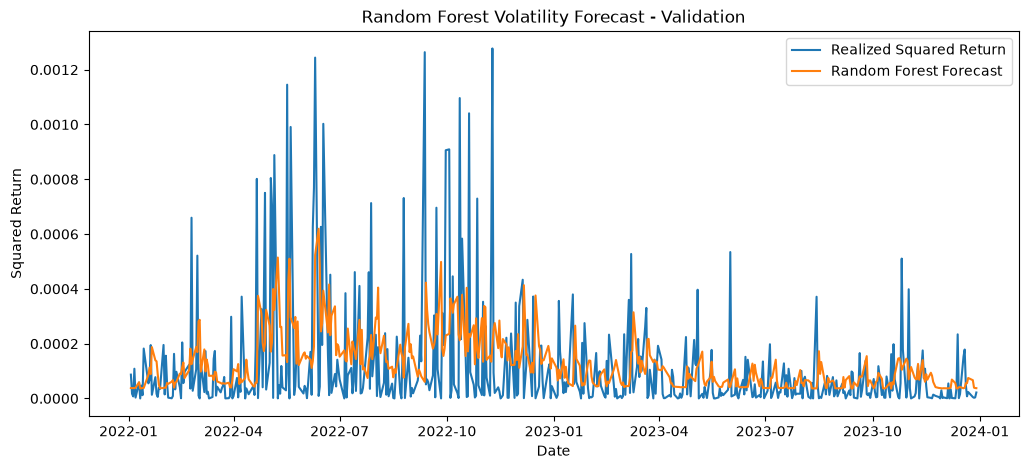

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(y_val_var.index, y_val_var, label="Realized Squared Return")
plt.plot(y_val_var.index, val_predictions, label="Random Forest Forecast")
plt.title("Random Forest Volatility Forecast - Validation")
plt.xlabel("Date")
plt.ylabel("Squared Return")
plt.legend()
plt.show()

Calibrate the Random Forest tail using standardized validation returns, then retrain the Random Forest on all pre-2024 observations while keeping the calibrated tail quantile fixed.

In [16]:
predicted_sigma_val = np.sqrt(val_predictions)
r_val_next = validation["target_return"]

z_val = r_val_next.to_numpy() / predicted_sigma_val
q_rf = np.quantile(z_val, ALPHA)

print("Empirical RF 1% standardized-return quantile:", q_rf)

train_final = ml_data[ml_data.index < "2024-01-01"]
X_train_final = train_final[feature_cols]
y_train_final_var = train_final["target_variance"]

rf_final = RandomForestRegressor(
    n_estimators=500,
    max_depth=6,
    min_samples_leaf=10,
    random_state=SEED,
    n_jobs=-1,
)

rf_final.fit(X_train_final, y_train_final_var)

rf_test_variance = np.maximum(rf_final.predict(X_test), 0)
rf_test_sigma = np.sqrt(rf_test_variance)

rf_var_feature_dates = pd.Series(
    rf_test_sigma * q_rf,
    index=test.index,
    name="RF_VaR",
)

Empirical RF 1% standardized-return quantile: -2.89579655669786


## 9. Align all one-step forecasts to the return date they predict

In [17]:
next_date_map = pd.Series(
    portfolio_returns.index[1:],
    index=portfolio_returns.index[:-1],
)

forecast_dates = next_date_map.loc[test.index]

actual_test_returns = pd.Series(
    test["target_return"].to_numpy(),
    index=forecast_dates.to_numpy(),
    name="Actual_Return",
)

rf_var_aligned = pd.Series(
    rf_var_feature_dates.to_numpy(),
    index=forecast_dates.to_numpy(),
    name="RF_VaR",
)

# Restrict GARCH to exactly the same return dates.
garch_var_aligned = garch_var_fixed.reindex(actual_test_returns.index)

print(pd.concat(
    [actual_test_returns, rf_var_aligned, garch_var_aligned],
    axis=1,
).head())

            Actual_Return    RF_VaR  GARCH_VaR
2024-01-03      -0.001925 -0.018770  -0.016450
2024-01-04      -0.005850 -0.018974  -0.015834
2024-01-05       0.003948 -0.019197  -0.016298
2024-01-08       0.003780 -0.018457  -0.015740
2024-01-09      -0.005985 -0.018679  -0.015221


## 10. Gaussian neural conditional diffusion

In [18]:
y_train_return = train["target_return"]
y_val_return = validation["target_return"]

# Hyperparameter-selection scaler: fit only on the initial training period.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)

y_train_t = torch.tensor(
    y_train_return.to_numpy(),
    dtype=torch.float32,
).reshape(-1, 1)

y_val_t = torch.tensor(
    y_val_return.to_numpy(),
    dtype=torch.float32,
).reshape(-1, 1)

In [19]:
class NeuralDiffusionGaussian(nn.Module):
    def __init__(self, n_features):
        super().__init__()

        self.shared = nn.Sequential(
            nn.Linear(n_features, 32),
            nn.Tanh(),
            nn.Linear(32, 16),
            nn.Tanh(),
        )

        self.drift = nn.Linear(16, 1)

        self.diffusion = nn.Sequential(
            nn.Linear(16, 1),
            nn.Softplus(),
        )

    def forward(self, x):
        h = self.shared(x)
        mu = self.drift(h)
        sigma = self.diffusion(h) + 1e-6
        return mu, sigma


def gaussian_nll(y, mu, sigma):
    return torch.mean(
        torch.log(sigma)
        + 0.5 * ((y - mu) / sigma) ** 2
    )

Use 2022–2023 only to select the training duration. Then retrain from scratch on all pre-2024 data for the selected number of epochs.

Best Gaussian validation epoch: 149
Best Gaussian validation NLL: -4.054280757904053


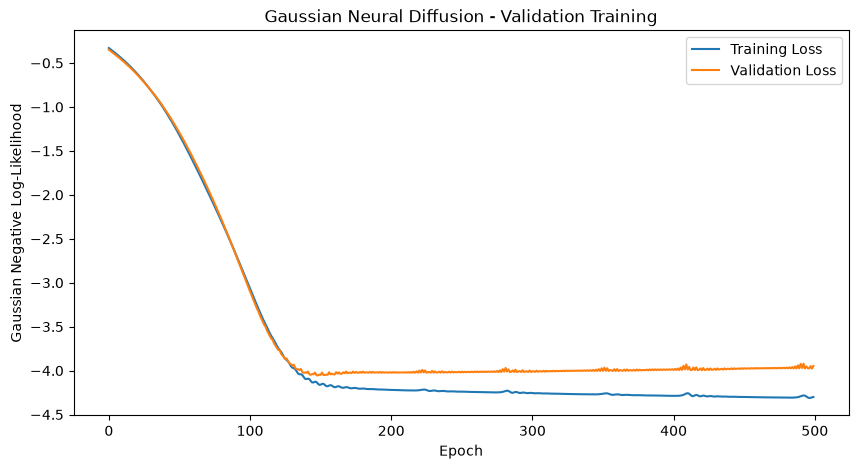

In [20]:
torch.manual_seed(SEED)

gaussian_val_model = NeuralDiffusionGaussian(len(feature_cols))
optimizer = torch.optim.Adam(
    gaussian_val_model.parameters(),
    lr=0.001,
    weight_decay=1e-5,
)

train_losses = []
val_losses = []

best_val_loss = np.inf
best_epoch_gaussian = 1
n_epochs = 500

for epoch in range(1, n_epochs + 1):
    gaussian_val_model.train()
    optimizer.zero_grad()

    mu_train, sigma_train = gaussian_val_model(X_train_t)
    train_loss = gaussian_nll(y_train_t, mu_train, sigma_train)

    train_loss.backward()
    optimizer.step()

    gaussian_val_model.eval()

    with torch.no_grad():
        mu_val, sigma_val = gaussian_val_model(X_val_t)
        val_loss = gaussian_nll(y_val_t, mu_val, sigma_val)

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_epoch_gaussian = epoch

print("Best Gaussian validation epoch:", best_epoch_gaussian)
print("Best Gaussian validation NLL:", best_val_loss)

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Gaussian Negative Log-Likelihood")
plt.title("Gaussian Neural Diffusion - Validation Training")
plt.legend()
plt.show()

In [21]:
# Final scaler and tensors use all pre-2024 information.
X_pre2024 = train_final[feature_cols]
y_pre2024_return = train_final["target_return"]

final_scaler = StandardScaler()
X_pre2024_scaled = final_scaler.fit_transform(X_pre2024)
X_test_scaled = final_scaler.transform(X_test)

X_pre2024_t = torch.tensor(X_pre2024_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

y_pre2024_t = torch.tensor(
    y_pre2024_return.to_numpy(),
    dtype=torch.float32,
).reshape(-1, 1)

torch.manual_seed(SEED)

gaussian_model = NeuralDiffusionGaussian(len(feature_cols))
optimizer_final = torch.optim.Adam(
    gaussian_model.parameters(),
    lr=0.001,
    weight_decay=1e-5,
)

for _ in range(best_epoch_gaussian):
    gaussian_model.train()
    optimizer_final.zero_grad()

    mu_full, sigma_full = gaussian_model(X_pre2024_t)
    loss_full = gaussian_nll(y_pre2024_t, mu_full, sigma_full)

    loss_full.backward()
    optimizer_final.step()

gaussian_model.eval()

with torch.no_grad():
    mu_test_gauss, sigma_test_gauss = gaussian_model(X_test_t)

mu_test_gauss = mu_test_gauss.numpy().flatten()
sigma_test_gauss = sigma_test_gauss.numpy().flatten()

# Exact one-step Gaussian 1% quantile; no Monte Carlo noise is needed.
gaussian_sde_var = mu_test_gauss + sigma_test_gauss * norm.ppf(ALPHA)

gaussian_sde_var_aligned = pd.Series(
    gaussian_sde_var,
    index=forecast_dates.to_numpy(),
    name="Gaussian_Neural_VaR",
)

## 11. Student-t neural conditional diffusion

In [22]:
class NeuralDiffusionStudentT(nn.Module):
    def __init__(self, n_features):
        super().__init__()

        self.shared = nn.Sequential(
            nn.Linear(n_features, 32),
            nn.Tanh(),
            nn.Linear(32, 16),
            nn.Tanh(),
        )

        self.drift = nn.Linear(16, 1)

        self.diffusion = nn.Sequential(
            nn.Linear(16, 1),
            nn.Softplus(),
        )

        self.raw_nu = nn.Parameter(torch.tensor(2.0))

    def forward(self, x):
        h = self.shared(x)
        mu = self.drift(h)
        sigma = self.diffusion(h) + 1e-6
        return mu, sigma

    def nu(self):
        # Finite variance: nu > 2.
        return 2.0 + torch.nn.functional.softplus(self.raw_nu)


def student_t_nll(y, mu, sigma, nu):
    # PyTorch StudentT uses scale, while sigma is interpreted here
    # as conditional standard deviation.
    scale = sigma * torch.sqrt((nu - 2.0) / nu)

    dist = torch.distributions.StudentT(
        df=nu,
        loc=mu,
        scale=scale,
    )

    return -dist.log_prob(y).mean()

Best Student-t validation epoch: 153
Best Student-t validation NLL: -3.1386072635650635
Validation-stage nu: 4.001765251159668


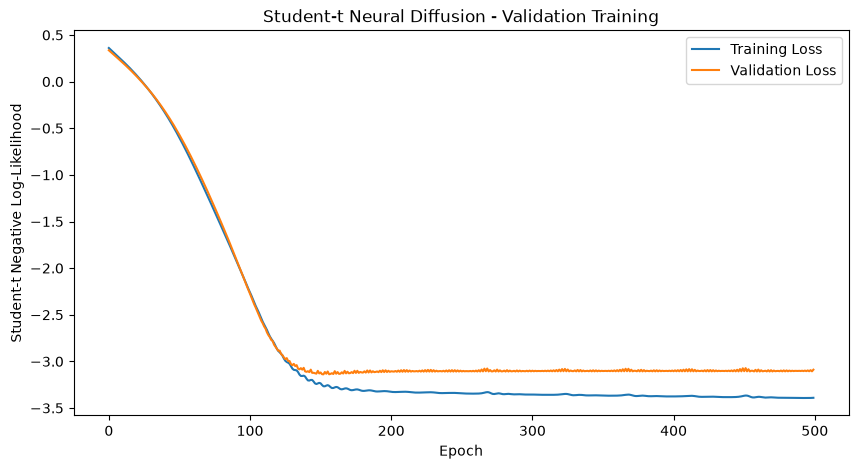

In [23]:
torch.manual_seed(SEED)

student_val_model = NeuralDiffusionStudentT(len(feature_cols))
optimizer_t = torch.optim.Adam(
    student_val_model.parameters(),
    lr=0.001,
    weight_decay=1e-5,
)

train_losses_t = []
val_losses_t = []

best_val_loss_t = np.inf
best_epoch_student = 1
n_epochs = 500

for epoch in range(1, n_epochs + 1):
    student_val_model.train()
    optimizer_t.zero_grad()

    mu_train, sigma_train = student_val_model(X_train_t)
    nu_train = student_val_model.nu()

    train_loss = student_t_nll(
        y_train_t,
        mu_train,
        sigma_train,
        nu_train,
    )

    train_loss.backward()
    optimizer_t.step()

    student_val_model.eval()

    with torch.no_grad():
        mu_val, sigma_val = student_val_model(X_val_t)
        nu_val = student_val_model.nu()

        val_loss = student_t_nll(
            y_val_t,
            mu_val,
            sigma_val,
            nu_val,
        )

    train_losses_t.append(train_loss.item())
    val_losses_t.append(val_loss.item())

    if val_loss.item() < best_val_loss_t:
        best_val_loss_t = val_loss.item()
        best_epoch_student = epoch

print("Best Student-t validation epoch:", best_epoch_student)
print("Best Student-t validation NLL:", best_val_loss_t)
print("Validation-stage nu:", student_val_model.nu().item())

plt.figure(figsize=(10, 5))
plt.plot(train_losses_t, label="Training Loss")
plt.plot(val_losses_t, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Student-t Negative Log-Likelihood")
plt.title("Student-t Neural Diffusion - Validation Training")
plt.legend()
plt.show()

In [24]:
torch.manual_seed(SEED)

student_model = NeuralDiffusionStudentT(len(feature_cols))
optimizer_student_final = torch.optim.Adam(
    student_model.parameters(),
    lr=0.001,
    weight_decay=1e-5,
)

for _ in range(best_epoch_student):
    student_model.train()
    optimizer_student_final.zero_grad()

    mu_full, sigma_full = student_model(X_pre2024_t)
    nu_full = student_model.nu()

    loss_full = student_t_nll(
        y_pre2024_t,
        mu_full,
        sigma_full,
        nu_full,
    )

    loss_full.backward()
    optimizer_student_final.step()

student_model.eval()

with torch.no_grad():
    mu_test_student, sigma_test_student = student_model(X_test_t)
    nu_test_student = student_model.nu().item()

mu_test_student = mu_test_student.numpy().flatten()
sigma_test_student = sigma_test_student.numpy().flatten()

student_q = (
    t.ppf(ALPHA, df=nu_test_student)
    * np.sqrt((nu_test_student - 2) / nu_test_student)
)

student_sde_var = (
    mu_test_student
    + sigma_test_student * student_q
)

student_sde_var_aligned = pd.Series(
    student_sde_var,
    index=forecast_dates.to_numpy(),
    name="StudentT_Neural_VaR",
)

print("Final Student-t neural degrees of freedom:", nu_test_student)

Final Student-t neural degrees of freedom: 4.007335662841797


## 12. Final out-of-sample comparison

In [25]:
final_comparison = pd.concat(
    [
        actual_test_returns,
        garch_var_aligned,
        rf_var_aligned,
        gaussian_sde_var_aligned,
        student_sde_var_aligned,
    ],
    axis=1,
).dropna()

print(final_comparison.head())
print("Common test observations:", len(final_comparison))

            Actual_Return  GARCH_VaR    RF_VaR  Gaussian_Neural_VaR  \
2024-01-03      -0.001925  -0.016450 -0.018770            -0.021759   
2024-01-04      -0.005850  -0.015834 -0.018974            -0.022545   
2024-01-05       0.003948  -0.016298 -0.019197            -0.023436   
2024-01-08       0.003780  -0.015740 -0.018457            -0.022807   
2024-01-09      -0.005985  -0.015221 -0.018679            -0.022943   

            StudentT_Neural_VaR  
2024-01-03            -0.026577  
2024-01-04            -0.027831  
2024-01-05            -0.028557  
2024-01-08            -0.028329  
2024-01-09            -0.028625  
Common test observations: 684


In [26]:
model_columns = {
    "GARCH-t": "GARCH_VaR",
    "Random Forest": "RF_VaR",
    "Gaussian Neural Diffusion": "Gaussian_Neural_VaR",
    "Student-t Neural Diffusion": "StudentT_Neural_VaR",
}

backtest_results = {}
loss_series = {}

for model_name, column in model_columns.items():
    result = var_backtest(
        final_comparison["Actual_Return"],
        final_comparison[column],
        alpha=ALPHA,
    )

    backtest_results[model_name] = result
    loss_series[model_name] = result["loss_series"]

results_table = pd.DataFrame(
    {
        model_name: {
            "Observations": result["n"],
            "Violations": result["violations"],
            "Violation Rate": result["violation_rate"],
            "Kupiec p-value": result["p_uc"],
            "Christoffersen p-value": result["p_ind"],
            "Conditional Coverage p-value": result["p_cc"],
            "Mean Quantile Loss": result["mean_quantile_loss"],
        }
        for model_name, result in backtest_results.items()
    }
).T

print(results_table)

                            Observations  Violations  Violation Rate  \
GARCH-t                       684.000000    7.000000        0.010234   
Random Forest                 684.000000    4.000000        0.005848   
Gaussian Neural Diffusion     684.000000    2.000000        0.002924   
Student-t Neural Diffusion    684.000000    1.000000        0.001462   

                            Kupiec p-value  Christoffersen p-value  \
GARCH-t                           0.951160                0.055242   
Random Forest                     0.236732                0.013667   
Gaussian Neural Diffusion         0.028527                0.913690   
Student-t Neural Diffusion        0.004986                0.956813   

                            Conditional Coverage p-value  Mean Quantile Loss  
GARCH-t                                         0.158934            0.000296  
Random Forest                                   0.023747            0.000299  
Gaussian Neural Diffusion                       0.0

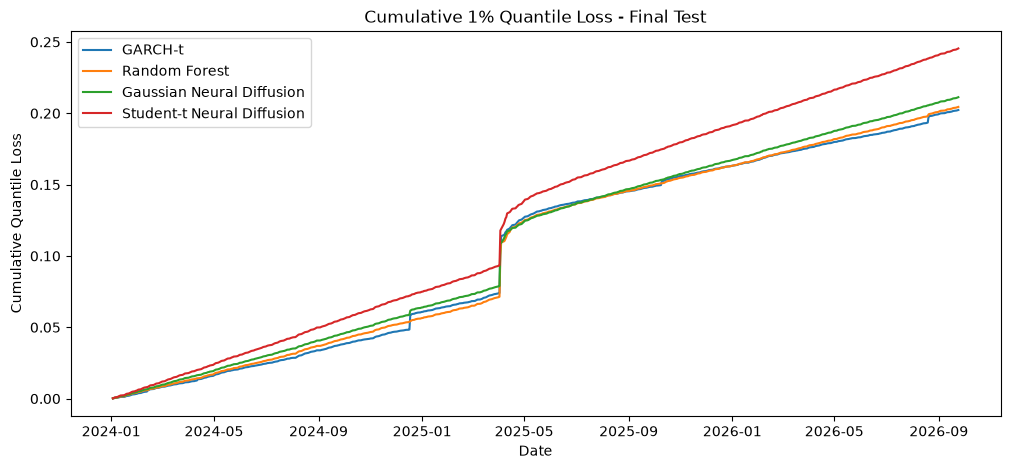

In [27]:
plt.figure(figsize=(12, 5))

for model_name, losses in loss_series.items():
    plt.plot(
        losses.index,
        losses.cumsum(),
        label=model_name,
    )

plt.title("Cumulative 1% Quantile Loss - Final Test")
plt.xlabel("Date")
plt.ylabel("Cumulative Quantile Loss")
plt.legend()
plt.show()

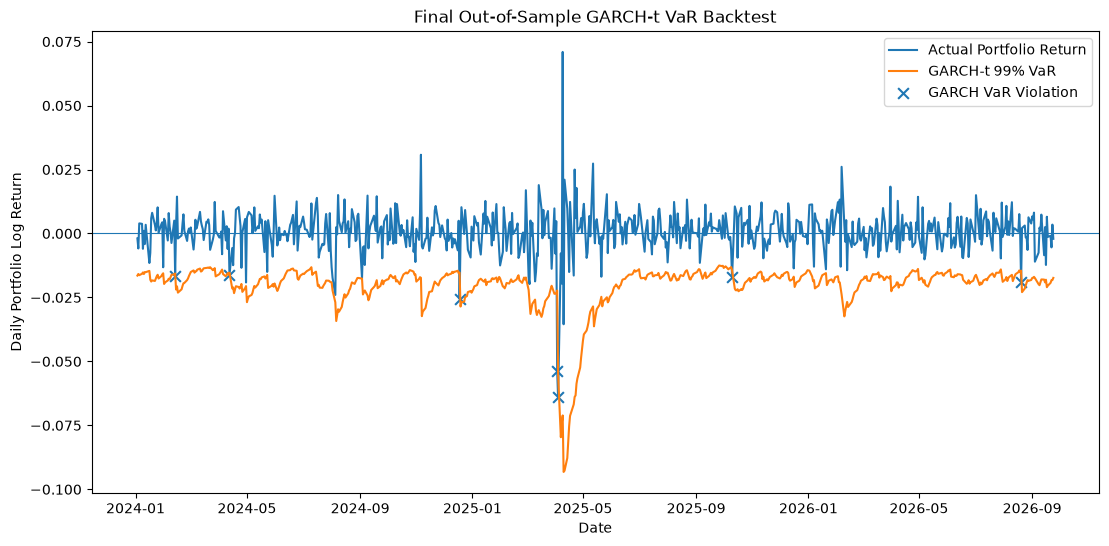

In [28]:
plt.figure(figsize=(13, 6))

plt.plot(
    final_comparison.index,
    final_comparison["Actual_Return"],
    label="Actual Portfolio Return",
)

plt.plot(
    final_comparison.index,
    final_comparison["GARCH_VaR"],
    label="GARCH-t 99% VaR",
)

garch_violations = (
    final_comparison["Actual_Return"]
    < final_comparison["GARCH_VaR"]
)

plt.scatter(
    final_comparison.index[garch_violations],
    final_comparison.loc[garch_violations, "Actual_Return"],
    marker="x",
    s=60,
    label="GARCH VaR Violation",
)

plt.axhline(0, linewidth=0.8)
plt.title("Final Out-of-Sample GARCH-t VaR Backtest")
plt.xlabel("Date")
plt.ylabel("Daily Portfolio Log Return")
plt.legend()
plt.show()

## 13. Interpretation

The final out-of-sample comparison shows that GARCH-t and Random Forest provide the strongest overall VaR performance on the common 2024–2026 test period.

GARCH-t produces a violation rate close to the nominal 1% level and achieves the lowest mean quantile loss among the models considered.

Random Forest performs similarly on quantile loss, although its violation independence result is weaker.

The Gaussian and Student-t neural diffusion models are more conservative, generating substantially fewer violations than expected under a correctly calibrated 99% VaR model.

Overall, the results suggest that increasing model flexibility does not automatically improve tail-risk forecasting, and that a relatively parsimonious GARCH-t specification remains highly competitive.